In [ ]:
#importar librerias
import json
import copy
import matplotlib.pyplot as plt
import numpy as np
import sys
from pathlib import Path
import os
import math
import pandas as pd
from scipy.stats import kruskal

### ANALISIS

### importar todo los resultados 

In [82]:
def cargar_resultados_sudoku(config_path, n_instancias):
    filas = []

    with open(config_path, "r") as file:
        config = json.load(file)

    archivo_salida = config["Archivo salida"]
    n_experimentos = config["N experimentos"]
    dataset = config["Dataset"]
    restriccion_tiempo = config["Restriccion tiempo"]

    for instancia in range(1, n_instancias + 1):
        for experimento in range(n_experimentos):
            ruta_resultado = f"{archivo_salida}_{instancia}_{experimento}.json"

            if not Path(ruta_resultado).exists():
                print(f"No existe: {ruta_resultado}")
                continue

            with open(ruta_resultado, "r") as file:
                resultado = json.load(file)

            fila = {
                "dataset": dataset,
                "instancia": instancia,
                "experimento": experimento,
                "restriccion_tiempo": restriccion_tiempo,
                "archivo_resultado": ruta_resultado,
            }

            # mete todo lo que venga en el json de resultado como columnas
            for key, value in resultado.items():
                fila[key] = value

            filas.append(fila)

    df = pd.DataFrame(filas)
    return df

### algoritmo memetico, dataset puzzles

In [57]:
df_m_p = cargar_resultados_sudoku("../experimentos/memetic_puzzles.json", n_instancias=25)
pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)
pd.set_option("display.width", None)
print(df_m_p.to_string(index=False))

      dataset  instancia  experimento  restriccion_tiempo                               archivo_resultado   Desvest  Mejor fitness  Peor fitness  Promedio
SudokuPuzzles          1            0                 200   ../resultados/SudokuPuzzles_Memetico_1_0.json 13.497834            8.0         144.0     11.48
SudokuPuzzles          1            1                 200   ../resultados/SudokuPuzzles_Memetico_1_1.json 12.758582           14.0         144.0     18.92
SudokuPuzzles          1            2                 200   ../resultados/SudokuPuzzles_Memetico_1_2.json 12.904686           12.0         144.0     17.88
SudokuPuzzles          1            3                 200   ../resultados/SudokuPuzzles_Memetico_1_3.json 13.114631           12.0         144.0     14.92
SudokuPuzzles          1            4                 200   ../resultados/SudokuPuzzles_Memetico_1_4.json 12.794112           16.0         144.0     17.74
SudokuPuzzles          1            5                 200   ../resulta

### algoritmo memetico, dataset logic-solved

In [58]:
df_m_l = cargar_resultados_sudoku("../experimentos/memetic_logic.json", n_instancias=15)
pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)
pd.set_option("display.width", None)
print(df_m_l.to_string(index=False))

 dataset  instancia  experimento  restriccion_tiempo                          archivo_resultado   Desvest  Mejor fitness  Peor fitness  Promedio
Solvable          1            0                 200   ../resultados/Solvable_Memetico_1_0.json 16.576727           20.0         186.0     22.20
Solvable          1            1                 200   ../resultados/Solvable_Memetico_1_1.json 16.772500           16.0         186.0     20.42
Solvable          1            2                 200   ../resultados/Solvable_Memetico_1_2.json 17.383831           12.0         186.0     14.38
Solvable          1            3                 200   ../resultados/Solvable_Memetico_1_3.json 17.680109            8.0         186.0     11.86
Solvable          1            4                 200   ../resultados/Solvable_Memetico_1_4.json 16.985068           16.0         186.0     18.18
Solvable          1            5                 200   ../resultados/Solvable_Memetico_1_5.json 17.564887            8.0         1

### algoritmo recocido, dataset puzzles

In [59]:
df_r_p = cargar_resultados_sudoku("../experimentos/recocido_puzzles.json", n_instancias=25)
pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)
pd.set_option("display.width", None)
print(df_r_p.to_string(index=False))

      dataset  instancia  experimento  restriccion_tiempo                               archivo_resultado  Desvest  Mejor fitness  Peor fitness  Promedio
SudokuPuzzles          1            0                 200   ../resultados/SudokuPuzzles_Recocido_1_0.json      0.0           54.0          54.0       0.0
SudokuPuzzles          1            1                 200   ../resultados/SudokuPuzzles_Recocido_1_1.json      0.0           54.0          54.0       0.0
SudokuPuzzles          1            2                 200   ../resultados/SudokuPuzzles_Recocido_1_2.json      0.0           56.0          56.0       0.0
SudokuPuzzles          1            3                 200   ../resultados/SudokuPuzzles_Recocido_1_3.json      0.0           58.0          58.0       0.0
SudokuPuzzles          1            4                 200   ../resultados/SudokuPuzzles_Recocido_1_4.json      0.0           50.0          50.0       0.0
SudokuPuzzles          1            5                 200   ../resultados/Su

### algoritmo recocido, dataset logic-solved

In [60]:
df_r_l = cargar_resultados_sudoku("../experimentos/recocido_logic.json", n_instancias=15)
pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)
pd.set_option("display.width", None)
print(df_r_l.to_string(index=False))

 dataset  instancia  experimento  restriccion_tiempo                          archivo_resultado  Desvest  Mejor fitness  Peor fitness  Promedio
Solvable          1            0                 500   ../resultados/Solvable_Recocido_1_0.json      0.0           52.0          52.0       0.0
Solvable          1            1                 500   ../resultados/Solvable_Recocido_1_1.json      0.0           50.0          50.0       0.0
Solvable          1            2                 500   ../resultados/Solvable_Recocido_1_2.json      0.0           56.0          56.0       0.0
Solvable          1            3                 500   ../resultados/Solvable_Recocido_1_3.json      0.0           48.0          48.0       0.0
Solvable          1            4                 500   ../resultados/Solvable_Recocido_1_4.json      0.0           50.0          50.0       0.0
Solvable          1            5                 500   ../resultados/Solvable_Recocido_1_5.json      0.0           52.0          52.0   

### lo juntamos todo en uno solo

In [63]:
col_fitness = "Mejor fitness"

# Copias
df_m_p = df_m_p.copy()
df_m_l = df_m_l.copy()
df_r_p = df_r_p.copy()
df_r_l = df_r_l.copy()

# Etiquetas
df_m_p["algoritmo"] = "memetico"
df_m_p["dataset"] = "puzzles"

df_m_l["algoritmo"] = "memetico"
df_m_l["dataset"] = "logic"

df_r_p["algoritmo"] = "recocido"
df_r_p["dataset"] = "puzzles"

df_r_l["algoritmo"] = "recocido"
df_r_l["dataset"] = "logic"

# Unir todo
df_all = pd.concat([df_m_p, df_m_l, df_r_p, df_r_l], ignore_index=True)

### normalizamos los fitness

In [64]:
def normalizar_por_instancia(x):
    if x.max() == x.min():
        return 0
    return (x - x.min()) / (x.max() - x.min())

df_all["fitness_norm"] = df_all.groupby(["dataset", "instancia"])[col_fitness].transform(normalizar_por_instancia)

### aplicamos kruskal wallis general

In [ ]:
#dividimos entre los algoritmos
memetico = df_all[df_all["algoritmo"] == "memetico"]["fitness_norm"]
recocido = df_all[df_all["algoritmo"] == "recocido"]["fitness_norm"]

#aplicamos kruskal
stat, p = kruskal(memetico, recocido)

print("Kruskal-Wallis general")
print("H =", stat)
print("p-value =", p)

print("\nMedianas normalizadas:")
print(df_all.groupby("algoritmo")["fitness_norm"].median())

mejor = df_all.groupby("algoritmo")["fitness_norm"].median().idxmin()
print("\nMejor algoritmo general:", mejor)

Kruskal-Wallis general
H = 1799.5083750201984
p-value = 0.0

Medianas normalizadas:
algoritmo
memetico    0.111111
recocido    0.884615
Name: fitness_norm, dtype: float64

Mejor algoritmo general: memetico


In [89]:
memetico = df_all[df_all["algoritmo"] == "memetico"]["fitness_norm"]
recocido = df_all[df_all["algoritmo"] == "recocido"]["fitness_norm"]

H, p = kruskal(memetico, recocido)

medianas = df_all.groupby("algoritmo")["fitness_norm"].median()

tabla_kw_general = pd.DataFrame({
    "Comparación": ["General"],
    "H": [H],
    "p-value": [p],
    "Mediana memético": [medianas["memetico"]],
    "Mediana recocido": [medianas["recocido"]],
    "Mejor algoritmo": [medianas.idxmin()]
})

latex_tabla = tabla_kw_general.to_latex(
    index=False,
    float_format="%.3f",
    caption="Prueba de Kruskal-Wallis general entre algoritmos",
    label="tab:kw_general"
)
print("Tabla en latex")
print(latex_tabla)

Tabla en latex
\begin{table}
\caption{Prueba de Kruskal-Wallis general entre algoritmos}
\label{tab:kw_general}
\begin{tabular}{lrrrrl}
\toprule
Comparación & H & p-value & Mediana memético & Mediana recocido & Mejor algoritmo \\
\midrule
General & 1799.508 & 0.000 & 0.111 & 0.885 & memetico \\
\bottomrule
\end{tabular}
\end{table}



### vemos dataset por dataset cuál fue mejor en cada caso

In [66]:
for dataset in df_all["dataset"].unique():
    df_d = df_all[df_all["dataset"] == dataset]

    memetico = df_d[df_d["algoritmo"] == "memetico"]["fitness_norm"]
    recocido = df_d[df_d["algoritmo"] == "recocido"]["fitness_norm"]

    stat, p = kruskal(memetico, recocido)

    print("\n" + "="*60)
    print("Dataset:", dataset)
    print("H =", stat)
    print("p-value =", p)
    print("Medianas normalizadas:")
    print(df_d.groupby("algoritmo")["fitness_norm"].median())

    mejor = df_d.groupby("algoritmo")["fitness_norm"].median().idxmin()
    print("Mejor según mediana:", mejor)


Dataset: puzzles
H = 1124.2334818355864
p-value = 1.7861897397296396e-246
Medianas normalizadas:
algoritmo
memetico    0.120000
recocido    0.888889
Name: fitness_norm, dtype: float64
Mejor según mediana: memetico

Dataset: logic
H = 674.9450044811165
p-value = 8.398839172334302e-149
Medianas normalizadas:
algoritmo
memetico    0.066679
recocido    0.846154
Name: fitness_norm, dtype: float64
Mejor según mediana: memetico


In [87]:
filas_kw_dataset = []

for dataset in sorted(df_all["dataset"].unique()):
    df_d = df_all[df_all["dataset"] == dataset]

    memetico = df_d[df_d["algoritmo"] == "memetico"]["fitness_norm"]
    recocido = df_d[df_d["algoritmo"] == "recocido"]["fitness_norm"]

    H, p = kruskal(memetico, recocido)

    medianas = df_d.groupby("algoritmo")["fitness_norm"].median()

    filas_kw_dataset.append({
        "Dataset": dataset,
        "H": H,
        "p-value": p,
        "Mediana memético": medianas["memetico"],
        "Mediana recocido": medianas["recocido"],
        "Mejor algoritmo": medianas.idxmin()
    })

tabla_kw_dataset = pd.DataFrame(filas_kw_dataset)

print(tabla_kw_dataset)

latex_kw_dataset = tabla_kw_dataset.to_latex(
    index=False,
    float_format="%.4f",
    caption="Prueba de Kruskal-Wallis por dataset.",
    label="tab:kw_dataset"
)

print(latex_kw_dataset)

   Dataset            H        p-value  Mediana memético  Mediana recocido  \
0    logic   674.945004  8.398839e-149          0.066679          0.846154   
1  puzzles  1124.233482  1.786190e-246          0.120000          0.888889   

  Mejor algoritmo  
0        memetico  
1        memetico  
\begin{table}
\caption{Prueba de Kruskal-Wallis por dataset.}
\label{tab:kw_dataset}
\begin{tabular}{lrrrrl}
\toprule
Dataset & H & p-value & Mediana memético & Mediana recocido & Mejor algoritmo \\
\midrule
logic & 674.9450 & 0.0000 & 0.0667 & 0.8462 & memetico \\
puzzles & 1124.2335 & 0.0000 & 0.1200 & 0.8889 & memetico \\
\bottomrule
\end{tabular}
\end{table}



### vemos instancia por instancia cuál fue mejor

In [67]:
resumen = df_all.groupby(
    ["dataset", "instancia", "algoritmo"]
)[col_fitness].median().reset_index()

tabla = resumen.pivot_table(
    index=["dataset", "instancia"],
    columns="algoritmo",
    values=col_fitness
).reset_index()

tabla["ganador"] = tabla[["memetico", "recocido"]].idxmin(axis=1)

print(tabla.to_string(index=False))
print("\nConteo de ganadores:")
print(tabla["ganador"].value_counts())

dataset  instancia  memetico  recocido  ganador
  logic          1      12.0      52.0 memetico
  logic          2      13.0      52.0 memetico
  logic          3      12.0      50.0 memetico
  logic          4      12.0      51.0 memetico
  logic          5       0.0      28.0 memetico
  logic          6       4.0      28.0 memetico
  logic          7       9.0      50.0 memetico
  logic          8      12.0      50.0 memetico
  logic          9      15.0     118.0 memetico
  logic         10       2.0     100.0 memetico
  logic         11      12.0     121.0 memetico
  logic         12      14.0     117.0 memetico
  logic         13      12.0     121.0 memetico
  logic         14      11.0     114.0 memetico
  logic         15      12.0     113.0 memetico
puzzles          1      12.0      54.0 memetico
puzzles          2      13.0      58.0 memetico
puzzles          3      11.0      56.0 memetico
puzzles          4      14.0      56.0 memetico
puzzles          5      13.0      58.0 m

In [88]:
resumen = df_all.groupby(
    ["dataset", "instancia", "algoritmo"]
)[col_fitness].median().reset_index()

tabla_ganadores = resumen.pivot_table(
    index=["dataset", "instancia"],
    columns="algoritmo",
    values=col_fitness
).reset_index()

tabla_ganadores["Ganador"] = tabla_ganadores[["memetico", "recocido"]].idxmin(axis=1)

conteo_ganadores = tabla_ganadores.groupby(
    ["dataset", "Ganador"]
).size().reset_index(name="Número de instancias")

print(conteo_ganadores)

latex_conteo_ganadores = conteo_ganadores.to_latex(
    index=False,
    caption="Conteo de instancias ganadas por algoritmo.",
    label="tab:conteo_ganadores"
)

print(latex_conteo_ganadores)

   dataset   Ganador  Número de instancias
0    logic  memetico                    15
1  puzzles  memetico                    25
\begin{table}
\caption{Conteo de instancias ganadas por algoritmo.}
\label{tab:conteo_ganadores}
\begin{tabular}{llr}
\toprule
dataset & Ganador & Número de instancias \\
\midrule
logic & memetico & 15 \\
puzzles & memetico & 25 \\
\bottomrule
\end{tabular}
\end{table}



Al final el memético fue el mas dominante

### Las gráficas de boxplot para cada algoritmo en general

/var/folders/7_/zj3wq6l11k59wfw83z_4v31w0000gn/T/ipykernel_85937/743776923.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(datos, labels=["Memético", "Recocido"])


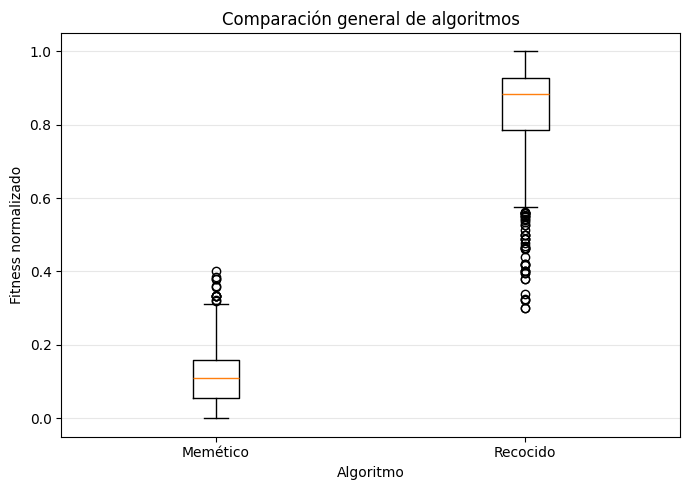

In [68]:
col_fitness = "fitness_norm"  # recomendado para comparar globalmente

datos = [
    df_all[df_all["algoritmo"] == "memetico"][col_fitness],
    df_all[df_all["algoritmo"] == "recocido"][col_fitness]
]

plt.figure(figsize=(7, 5))
plt.boxplot(datos, labels=["Memético", "Recocido"])

plt.title("Comparación general de algoritmos")
plt.xlabel("Algoritmo")
plt.ylabel("Fitness normalizado")
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

### las gráficas de boxplot para cada dataset en general

/var/folders/7_/zj3wq6l11k59wfw83z_4v31w0000gn/T/ipykernel_85937/1479275151.py:16: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(datos, labels=["Memético", "Recocido"])
/var/folders/7_/zj3wq6l11k59wfw83z_4v31w0000gn/T/ipykernel_85937/1479275151.py:16: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(datos, labels=["Memético", "Recocido"])


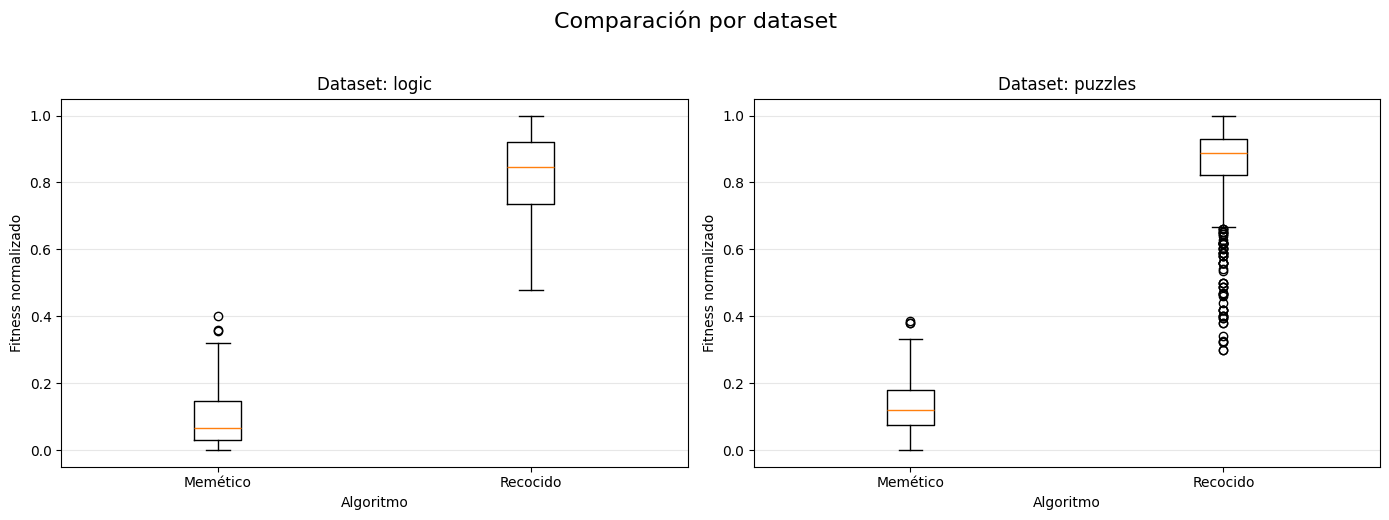

In [69]:
datasets = sorted(df_all["dataset"].unique())

fig, axes = plt.subplots(1, len(datasets), figsize=(7 * len(datasets), 5))

if len(datasets) == 1:
    axes = [axes]

for ax, dataset in zip(axes, datasets):
    df_d = df_all[df_all["dataset"] == dataset]

    datos = [
        df_d[df_d["algoritmo"] == "memetico"]["fitness_norm"],
        df_d[df_d["algoritmo"] == "recocido"]["fitness_norm"]
    ]

    ax.boxplot(datos, labels=["Memético", "Recocido"])
    ax.set_title(f"Dataset: {dataset}")
    ax.set_xlabel("Algoritmo")
    ax.set_ylabel("Fitness normalizado")
    ax.grid(axis="y", alpha=0.3)

plt.suptitle("Comparación por dataset", fontsize=16, y=1.03)
plt.tight_layout()
plt.show()

### ahora las tablas de resultados de promedio, desviación estandar, mejor y peor

In [79]:
col_fitness = "Mejor fitness"

tabla_resumen = df_all.groupby(["dataset", "algoritmo"]).agg(
    Media=(col_fitness, "mean"),
    Desviacion=(col_fitness, "std"),
    Mejor=(col_fitness, "min"),
    Peor=(col_fitness, "max"),
    SuccessRate=(col_fitness, lambda x: 100 * (x == 0).mean())
).reset_index()

print(tabla_resumen)

tabla_resumen = tabla_resumen.rename(columns={
    "dataset": "Dataset",
    "algoritmo": "Algoritmo"
})

latex_tabla = tabla_resumen.to_latex(
    index=False,
    float_format="%.3f",
    caption="Media, desviación estándar, mejor y peor fitness obtenido por algoritmo.",
    label="tab:estadisticas_algoritmos"
)
print("Tabla en latex")
print(latex_tabla)

   dataset algoritmo      Media  Desviacion  Mejor   Peor  SuccessRate
0    logic  memetico  10.315556    5.548569    0.0   24.0    12.444444
1    logic  recocido  77.946667   38.227042   18.0  172.0     0.000000
2  puzzles  memetico  19.362667   19.575855    4.0   80.0     0.000000
3  puzzles  recocido  63.149333   22.584104   36.0  160.0     0.000000
Tabla en latex
\begin{table}
\caption{Media, desviación estándar, mejor y peor fitness obtenido por algoritmo.}
\label{tab:estadisticas_algoritmos}
\begin{tabular}{llrrrrr}
\toprule
Dataset & Algoritmo & Media & Desviacion & Mejor & Peor & SuccessRate \\
\midrule
logic & memetico & 10.316 & 5.549 & 0.000 & 24.000 & 12.444 \\
logic & recocido & 77.947 & 38.227 & 18.000 & 172.000 & 0.000 \\
puzzles & memetico & 19.363 & 19.576 & 4.000 & 80.000 & 0.000 \\
puzzles & recocido & 63.149 & 22.584 & 36.000 & 160.000 & 0.000 \\
\bottomrule
\end{tabular}
\end{table}



In [81]:
tabla_instancias = df_all.groupby(
    ["dataset", "instancia", "algoritmo"]
).agg(
    Media=(col_fitness, "mean"),
    Desviacion=(col_fitness, "std"),
    Mejor=(col_fitness, "min"),
    Peor=(col_fitness, "max"),
    SuccessRate=(col_fitness, lambda x: 100 * (x == 0).mean())
).reset_index()

print(tabla_instancias)

tabla_instancias = tabla_instancias.rename(columns={
    "dataset": "Dataset",
    "instancia": "Instancia",
    "algoritmo": "Algoritmo",
    "SuccessRate": "Success rate (\\%)"
})

latex_instancias = tabla_instancias.to_latex(
    index=False,
    float_format="%.3f",
    caption="Resumen estadístico por instancia y algoritmo.",
    label="tab:estadisticas_instancias",
    escape=False
)

print(latex_instancias)

    dataset  instancia algoritmo       Media  Desviacion  Mejor   Peor  \
0     logic          1  memetico   11.666667    3.366502    8.0   20.0   
1     logic          1  recocido   50.933333    3.050532   44.0   56.0   
2     logic          2  memetico   13.333333    3.536347    4.0   18.0   
3     logic          2  recocido   52.266667    2.612085   46.0   58.0   
4     logic          3  memetico   11.466667    3.401149    4.0   18.0   
5     logic          3  recocido   50.000000    3.194823   42.0   54.0   
6     logic          4  memetico   12.200000    2.940795    4.0   16.0   
7     logic          4  recocido   50.933333    2.664367   44.0   56.0   
8     logic          5  memetico    0.000000    0.000000    0.0    0.0   
9     logic          5  recocido   27.600000    3.728733   18.0   32.0   
10    logic          6  memetico    3.333333    2.590877    0.0    8.0   
11    logic          6  recocido   27.333333    3.209182   20.0   32.0   
12    logic          7  memetico   10.

In [83]:
nombres_logic = {
    1: "aiescargot",
    2: "coly013",
    3: "goldennugget",
    4: "platinumblond",
    5: "reddwarf",
    6: "sabuncu1",
    7: "sabuncu10",
    8: "sabuncu2",
    9: "sabuncu3",
    10: "sabuncu4",
    11: "sabuncu5",
    12: "sabuncu6",
    13: "sabuncu7",
    14: "sabuncu8",
    15: "sabuncu9",
    16: "tarx0134",
}

tabla_logic = tabla_instancias[tabla_instancias["Dataset"] == "logic"].copy()

tabla_logic["Instancia paper"] = tabla_logic["Instancia"].map(nombres_logic)

acs_bve = {
    "sabuncu1":      {"ACS+BVE Success rate (%)": 100, "ACS+BVE Tiempo (s)": 4.8e-5},
    "sabuncu2":      {"ACS+BVE Success rate (%)": 100, "ACS+BVE Tiempo (s)": 4.82e-5},
    "sabuncu3":      {"ACS+BVE Success rate (%)": 100, "ACS+BVE Tiempo (s)": 0.000993},
    "sabuncu4":      {"ACS+BVE Success rate (%)": 100, "ACS+BVE Tiempo (s)": 0.000625},
    "sabuncu5":      {"ACS+BVE Success rate (%)": 100, "ACS+BVE Tiempo (s)": 4.62e-5},
    "sabuncu6":      {"ACS+BVE Success rate (%)": 100, "ACS+BVE Tiempo (s)": 0.0107},
    "sabuncu7":      {"ACS+BVE Success rate (%)": 100, "ACS+BVE Tiempo (s)": 0.00106},
    "sabuncu8":      {"ACS+BVE Success rate (%)": 100, "ACS+BVE Tiempo (s)": 0.000728},
    "sabuncu9":      {"ACS+BVE Success rate (%)": 100, "ACS+BVE Tiempo (s)": 0.00163},
    "sabuncu10":     {"ACS+BVE Success rate (%)": 100, "ACS+BVE Tiempo (s)": 4.73e-5},
    "aiescargot":    {"ACS+BVE Success rate (%)": 100, "ACS+BVE Tiempo (s)": 0.0204},
    "coly013":       {"ACS+BVE Success rate (%)": 100, "ACS+BVE Tiempo (s)": 0.0488},
    "goldennugget":  {"ACS+BVE Success rate (%)": 100, "ACS+BVE Tiempo (s)": 0.0374},
    "platinumblond": {"ACS+BVE Success rate (%)": 100, "ACS+BVE Tiempo (s)": 0.113},
    "reddwarf":      {"ACS+BVE Success rate (%)": 100, "ACS+BVE Tiempo (s)": 0.0404},
    "tarx0134":      {"ACS+BVE Success rate (%)": 100, "ACS+BVE Tiempo (s)": 0.0259},
}

df_acs = pd.DataFrame.from_dict(acs_bve, orient="index").reset_index()
df_acs = df_acs.rename(columns={"index": "Instancia paper"})

comparacion_logic = tabla_logic.merge(
    df_acs,
    on="Instancia paper",
    how="left"
)

comparacion_logic = comparacion_logic[
    [
        "Instancia",
        "Instancia paper",
        "Algoritmo",
        "Media",
        "Desviacion",
        "Mejor",
        "Peor",
        "Success rate (\\%)",
        "ACS+BVE Success rate (%)",
        "ACS+BVE Tiempo (s)",
    ]
]

print(comparacion_logic.to_string(index=False))

latex_comparacion = comparacion_logic.to_latex(
    index=False,
    float_format="%.3f",
    caption="Comparación por instancia contra ACS+BVE reportado por Lloyd y Amos.",
    label="tab:comparacion_acs_bve_instancia",
    escape=False
)

print(latex_comparacion)

 Instancia Instancia paper Algoritmo      Media  Desviacion  Mejor  Peor  Success rate (\%)  ACS+BVE Success rate (%)  ACS+BVE Tiempo (s)
         1      aiescargot  memetico  11.666667    3.366502    8.0  20.0           0.000000                       100            0.020400
         1      aiescargot  recocido  50.933333    3.050532   44.0  56.0           0.000000                       100            0.020400
         2         coly013  memetico  13.333333    3.536347    4.0  18.0           0.000000                       100            0.048800
         2         coly013  recocido  52.266667    2.612085   46.0  58.0           0.000000                       100            0.048800
         3    goldennugget  memetico  11.466667    3.401149    4.0  18.0           0.000000                       100            0.037400
         3    goldennugget  recocido  50.000000    3.194823   42.0  54.0           0.000000                       100            0.037400
         4   platinumblond  memeti

In [84]:
nombres_puzzles = {
    1: "Film1",
    2: "Film2",
    3: "Inkala",
    4: "SD1",
    5: "SD2",
    6: "SD3",
    7: "SS1",
    8: "SS10",
    9: "SS2",
    10: "SS3",
    11: "SS4",
    12: "SS5",
    13: "SS6",
    14: "SS7",
    15: "SS8",
    16: "SS9",
    17: "SW1",
    18: "SW10",
    19: "SW2",
    20: "SW3",
    21: "SW4",
    22: "SW5",
    23: "SW6",
    24: "SW7",
    25: "SW8",
    26: "SW9",
}

multi_dyn = {
    "SW1":    {"MULTI_DYN Success rate (%)": 100.0, "MULTI_DYN Tiempo (s)": 3.6},
    "SW2":    {"MULTI_DYN Success rate (%)": 100.0, "MULTI_DYN Tiempo (s)": 2.4},
    "SW3":    {"MULTI_DYN Success rate (%)": 100.0, "MULTI_DYN Tiempo (s)": 5.4},
    "SW4":    {"MULTI_DYN Success rate (%)": 100.0, "MULTI_DYN Tiempo (s)": 1.2},
    "SW5":    {"MULTI_DYN Success rate (%)": 100.0, "MULTI_DYN Tiempo (s)": 4.8},
    "SW6":    {"MULTI_DYN Success rate (%)": 100.0, "MULTI_DYN Tiempo (s)": 3.7},
    "SW7":    {"MULTI_DYN Success rate (%)": 100.0, "MULTI_DYN Tiempo (s)": 2.3},
    "SW8":    {"MULTI_DYN Success rate (%)": 100.0, "MULTI_DYN Tiempo (s)": 2.1},
    "SW9":    {"MULTI_DYN Success rate (%)": 100.0, "MULTI_DYN Tiempo (s)": 5.4},
    "SW10":   {"MULTI_DYN Success rate (%)": 100.0, "MULTI_DYN Tiempo (s)": 4.2},

    "SS1":    {"MULTI_DYN Success rate (%)": 100.0, "MULTI_DYN Tiempo (s)": 1.8},
    "SS2":    {"MULTI_DYN Success rate (%)": 100.0, "MULTI_DYN Tiempo (s)": 12.5},
    "SS3":    {"MULTI_DYN Success rate (%)": 100.0, "MULTI_DYN Tiempo (s)": 4.8},
    "SS4":    {"MULTI_DYN Success rate (%)": 100.0, "MULTI_DYN Tiempo (s)": 63.4},
    "SS5":    {"MULTI_DYN Success rate (%)": 100.0, "MULTI_DYN Tiempo (s)": 5.9},
    "SS6":    {"MULTI_DYN Success rate (%)": 100.0, "MULTI_DYN Tiempo (s)": 7.1},
    "SS7":    {"MULTI_DYN Success rate (%)": 100.0, "MULTI_DYN Tiempo (s)": 1.4},
    "SS8":    {"MULTI_DYN Success rate (%)": 100.0, "MULTI_DYN Tiempo (s)": 2.2},
    "SS9":    {"MULTI_DYN Success rate (%)": 100.0, "MULTI_DYN Tiempo (s)": 1.5},
    "SS10":   {"MULTI_DYN Success rate (%)": 100.0, "MULTI_DYN Tiempo (s)": 5.4},

    "SD1":    {"MULTI_DYN Success rate (%)": 100.0, "MULTI_DYN Tiempo (s)": 14.5},
    "SD2":    {"MULTI_DYN Success rate (%)": 100.0, "MULTI_DYN Tiempo (s)": 7.6},
    "SD3":    {"MULTI_DYN Success rate (%)": 100.0, "MULTI_DYN Tiempo (s)": 10.8},

    "Inkala": {"MULTI_DYN Success rate (%)": 100.0, "MULTI_DYN Tiempo (s)": 67.3},
    "Film1":  {"MULTI_DYN Success rate (%)": 83.3,  "MULTI_DYN Tiempo (s)": 155.0},
    "Film2":  {"MULTI_DYN Success rate (%)": 63.3,  "MULTI_DYN Tiempo (s)": 208.0},
}

tabla_puzzles = tabla_instancias[tabla_instancias["Dataset"] == "puzzles"].copy()

tabla_puzzles["Instancia paper"] = tabla_puzzles["Instancia"].map(nombres_puzzles)

df_multi_dyn = pd.DataFrame.from_dict(multi_dyn, orient="index").reset_index()
df_multi_dyn = df_multi_dyn.rename(columns={"index": "Instancia paper"})

comparacion_puzzles = tabla_puzzles.merge(
    df_multi_dyn,
    on="Instancia paper",
    how="left"
)

comparacion_puzzles = comparacion_puzzles[
    [
        "Instancia",
        "Instancia paper",
        "Algoritmo",
        "Media",
        "Desviacion",
        "Mejor",
        "Peor",
        "Success rate (\\%)",
        "MULTI_DYN Success rate (%)",
        "MULTI_DYN Tiempo (s)",
    ]
]

print(comparacion_puzzles.to_string(index=False))

latex_comparacion_puzzles = comparacion_puzzles.to_latex(
    index=False,
    float_format="%.3f",
    caption="Comparación por instancia contra MULTI DYN reportado por Segura et al.",
    label="tab:comparacion_multi_dyn_instancia",
    escape=False
)

print(latex_comparacion_puzzles)

 Instancia Instancia paper Algoritmo      Media  Desviacion  Mejor  Peor  Success rate (\%)  MULTI_DYN Success rate (%)  MULTI_DYN Tiempo (s)
         1           Film1  memetico  11.200000    3.661543    6.0  24.0                0.0                        83.3                 155.0
         1           Film1  recocido  53.533333    3.350073   46.0  60.0                0.0                        83.3                 155.0
         2           Film2  memetico  13.066667    3.885724    4.0  20.0                0.0                        63.3                 208.0
         2           Film2  recocido  58.200000    2.796550   52.0  64.0                0.0                        63.3                 208.0
         3          Inkala  memetico  11.466667    3.748410    4.0  20.0                0.0                       100.0                  67.3
         3          Inkala  recocido  55.533333    2.909359   48.0  60.0                0.0                       100.0                  67.3
      

### de aqui para abajo es solamente para hacer que los datasets sean legibles por mi codigo

In [14]:
def convertir_sudoku_archivo(archivo_entrada, archivo_salida=None):
    archivo_entrada = Path(archivo_entrada)

    if archivo_salida is None:
        archivo_salida = archivo_entrada.with_name(
            archivo_entrada.stem + "_convertido" + archivo_entrada.suffix
        )
    else:
        archivo_salida = Path(archivo_salida)

    with open(archivo_entrada, "r", encoding="utf-8") as f:
        datos = f.read().split()

    if len(datos) < 3:
        raise ValueError("El archivo no tiene suficientes datos.")

    # Primer número: orden del Sudoku
    orden = int(datos[0])

    # Segundo número: dummy/id/modo, se elimina
    # dummy = int(datos[1])

    # Resto: tablero
    valores = [int(x) for x in datos[2:]]

    n = orden ** 2
    celdas_esperadas = n * n

    if len(valores) != celdas_esperadas:
        raise ValueError(
            f"El Sudoku de orden {orden} debería tener {celdas_esperadas} celdas, "
            f"pero se encontraron {len(valores)}."
        )

    # Cambiar -1 por 0
    valores = [0 if x == -1 else x for x in valores]

    # Reconstruir tablero
    tablero = [
        valores[i * n:(i + 1) * n]
        for i in range(n)
    ]

    # Guardar archivo nuevo:
    # conserva el primer número, elimina el segundo, y escribe el tablero
    with open(archivo_entrada, "w", encoding="utf-8") as f:
        f.write(f"{orden}\n")
        for fila in tablero:
            f.write("\t".join(map(str, fila)) + "\n")

    print(f"Archivo convertido guardado en: {archivo_salida}")


if __name__ == "__main__":
    f = open('../datasets/instances/logic-solvable/instances.txt', 'r')
    file_contents = f.read().split()
    for file in file_contents:
        file_="../datasets/instances/logic-solvable/"+file
        archivo_entrada = file_

        archivo_salida = None

        convertir_sudoku_archivo(archivo_entrada, archivo_salida)

    f.close()

Archivo convertido guardado en: ../datasets/instances/logic-solvable/aiescargot_convertido.txt
Archivo convertido guardado en: ../datasets/instances/logic-solvable/coly013_convertido.txt
Archivo convertido guardado en: ../datasets/instances/logic-solvable/goldennugget_convertido.txt
Archivo convertido guardado en: ../datasets/instances/logic-solvable/platinumblond_convertido.txt
Archivo convertido guardado en: ../datasets/instances/logic-solvable/reddwarf_convertido.txt
Archivo convertido guardado en: ../datasets/instances/logic-solvable/sabuncu1_convertido.txt
Archivo convertido guardado en: ../datasets/instances/logic-solvable/sabuncu10_convertido.txt
Archivo convertido guardado en: ../datasets/instances/logic-solvable/sabuncu2_convertido.txt
Archivo convertido guardado en: ../datasets/instances/logic-solvable/sabuncu3_convertido.txt
Archivo convertido guardado en: ../datasets/instances/logic-solvable/sabuncu4_convertido.txt
Archivo convertido guardado en: ../datasets/instances/logic

In [17]:
def agregar_orden_sudoku(archivo_entrada, archivo_salida=None):
    archivo_entrada = Path(archivo_entrada)

    if archivo_salida is None:
        archivo_salida = archivo_entrada.with_name(
            archivo_entrada.stem + "_con_orden" + archivo_entrada.suffix
        )
    else:
        archivo_salida = Path(archivo_salida)

    # Leer tablero
    with open(archivo_entrada, "r", encoding="utf-8") as f:
        lineas = [linea.strip() for linea in f.readlines() if linea.strip()]

    tablero = []
    for linea in lineas:
        fila = list(map(int, linea.split()))
        tablero.append(fila)

    if not tablero:
        raise ValueError("El archivo está vacío.")

    alto = len(tablero)
    ancho = len(tablero[0])

    # Validar que todas las filas tengan el mismo ancho
    for i, fila in enumerate(tablero):
        if len(fila) != ancho:
            raise ValueError(
                f"La fila {i + 1} tiene {len(fila)} valores, "
                f"pero se esperaban {ancho}."
            )

    # Validar que sea cuadrado
    if alto != ancho:
        raise ValueError(
            f"El tablero debe ser cuadrado, pero tiene tamaño {alto}x{ancho}."
        )

    # Calcular raíz cuadrada del ancho
    orden = int(math.sqrt(ancho))

    if orden * orden != ancho:
        raise ValueError(
            f"El ancho {ancho} no tiene raíz cuadrada entera. "
            f"No parece ser un Sudoku válido."
        )

    # Escribir archivo nuevo
    with open(archivo_entrada, "w", encoding="utf-8") as f:
        f.write(f"{orden}\n")
        for fila in tablero:
            f.write(" ".join(map(str, fila)) + "\n")

    print(f"Archivo guardado en: {archivo_entrada}")


if __name__ == "__main__":

    f = open('../datasets/SudokuPuzzles/instances.txt', 'r')
    file_contents = f.read().split()
    for file in file_contents:
        file_="../datasets/SudokuPuzzles/"+file
        archivo_entrada = file_

        archivo_salida = None

        agregar_orden_sudoku(archivo_entrada, archivo_salida)

    f.close()

Archivo guardado en: ../datasets/SudokuPuzzles/David_Filmer1.txt
Archivo guardado en: ../datasets/SudokuPuzzles/David_Filmer2.txt
Archivo guardado en: ../datasets/SudokuPuzzles/Inkala.txt
Archivo guardado en: ../datasets/SudokuPuzzles/SD1.txt
Archivo guardado en: ../datasets/SudokuPuzzles/SD2.txt
Archivo guardado en: ../datasets/SudokuPuzzles/SD3.txt
Archivo guardado en: ../datasets/SudokuPuzzles/SudokuSolutionsCom_Hard1.txt
Archivo guardado en: ../datasets/SudokuPuzzles/SudokuSolutionsCom_Hard10.txt
Archivo guardado en: ../datasets/SudokuPuzzles/SudokuSolutionsCom_Hard2.txt
Archivo guardado en: ../datasets/SudokuPuzzles/SudokuSolutionsCom_Hard3.txt
Archivo guardado en: ../datasets/SudokuPuzzles/SudokuSolutionsCom_Hard4.txt
Archivo guardado en: ../datasets/SudokuPuzzles/SudokuSolutionsCom_Hard5.txt
Archivo guardado en: ../datasets/SudokuPuzzles/SudokuSolutionsCom_Hard6.txt
Archivo guardado en: ../datasets/SudokuPuzzles/SudokuSolutionsCom_Hard7.txt
Archivo guardado en: ../datasets/Sudok

In [12]:
f = open('../datasets/instances/general/instances.txt', 'r')
file_contents = f.read().split()
for file in file_contents:
    nombre_original = "../datasets/instances/general/"+file

    # Reemplaza "_copia" por ""
    resultante = nombre_original.replace("_convertido", "")

    os.rename(nombre_original, resultante)

f.close()

In [26]:
import json

archivo_entrada = "../datasets/SudokuPuzzles/instances.txt"
archivo_salida = "../datasets/SudokuPuzzles/instances.json"

lineas = []

with open(archivo_entrada, "r", encoding="utf-8") as f:
    for linea in f:
        linea = linea.strip()

        if linea == "":
            continue

        linea=linea.replace("_convertido", "")
        linea="../datasets/SudokuPuzzles/"+linea
        lineas.append(linea)
datos = {
    "Archivos": lineas
}

with open(archivo_salida, "w", encoding="utf-8") as f:
    json.dump(datos, f, indent=4, ensure_ascii=False)

print(f"Archivo guardado en: {archivo_salida}")

Archivo guardado en: ../datasets/SudokuPuzzles/instances.json


In [ ]:
with open(archivo_entrada, "r", encoding="utf-8") as f:
    datos = f.read().split()

In [37]:
#crear los jsons de los experimentos
seed_base=277010
dataset="Solvable"
optimizador="Recocido"

extras=[{   "N experimentos": 30,
            "N hilos": 30,
            "Dataset": dataset,
            "Restriccion tiempo": 200,
            "Archivo salida": "",

            "N": 3,
            "Seed": seed_base, 
            "N inds": 1,

            "Optimizador": optimizador,
            "Rep": "Filas",
            "Fitness func": 1,
            "Pesos": [1.0, 1.0],
            
            "Temp inicial": 10,
            "Temp final": 1e-5,
            "Cambio": 0.99999,
            "N swaps": 1,
            "Crossover": "Cut",
            "N swaps cambio": 1, 
            "N padres": 20,
            "N its": 100
            }
            for i in range(1)]

'''
extras=[{"Dataset":          dataset, 
         "N its":            200, 
         "N inds":           100, 
         "N experimentos":   1, 
         "Seed":             seed_base+i%10, 
         "Archivo salida":   "", #--------------------------------------
         "Archivo graficas": "", #--------------------------------------
         "Optimizador":      optimizador,
         "Lower bound":      -1.0, 
         "Upper bound":      1.0, 
         "Fitness":          "accuracy", 
         "F":                0.5, #--------------------------------------
         "C_r":              0.5, #--------------------------------------
         "N capas":          4,
         "Estructura":       [784, 128, 64, 10],
         "Activaciones":     ["ReLU", "ReLU", "ReLU", "nada"],
         "Verbose":          -1, 
         "Reporte":          "test",
         "Clip":             1, 
         "Normalizacion":    1,
         "Mutacion":         "pbest"}
         for i in range(len(Fs)*len(Fs[0]))]
'''
  
count=0
for i in range(len(extras)):
    extras[count]["Archivo salida"]="../resultados/"+dataset+"_"+optimizador

    count+=1


for i, nuevo_json in enumerate(extras):
    with open("../recocido_logic.json", "w", encoding="utf-8") as f:
        json.dump(nuevo_json, f, indent=4, ensure_ascii=False)



In [1]:
import fitz
import os

carpeta_pdf = "../papers"
carpeta_txt = "/Users/imauriciolopez/Downloads/papers_txt"

os.makedirs(carpeta_txt, exist_ok=True)

for archivo in os.listdir(carpeta_pdf):

    if archivo.endswith(".pdf"):

        ruta_pdf = os.path.join(carpeta_pdf, archivo)

        ruta_txt = os.path.join(carpeta_txt, archivo.replace(".pdf", ".txt"))

        doc = fitz.open(ruta_pdf)

        texto = ""

        for page in doc:

            texto += page.get_text() + "\n"

        with open(ruta_txt, "w", encoding="utf-8") as f:

            f.write(texto)

In [5]:
import math as mt
n=10
mat=[[j*n+i for i in range(n)] for j in range(n)]
mat_2=[i for i in range(n*n)]
mat_3=[[0 for i in range(n)] for j in range(n)]

for i in range(n*n):
    mat_3[i%n][mt.floor(i/n)]=mat_2[i]
mat_3

[[0, 10, 20, 30, 40, 50, 60, 70, 80, 90],
 [1, 11, 21, 31, 41, 51, 61, 71, 81, 91],
 [2, 12, 22, 32, 42, 52, 62, 72, 82, 92],
 [3, 13, 23, 33, 43, 53, 63, 73, 83, 93],
 [4, 14, 24, 34, 44, 54, 64, 74, 84, 94],
 [5, 15, 25, 35, 45, 55, 65, 75, 85, 95],
 [6, 16, 26, 36, 46, 56, 66, 76, 86, 96],
 [7, 17, 27, 37, 47, 57, 67, 77, 87, 97],
 [8, 18, 28, 38, 48, 58, 68, 78, 88, 98],
 [9, 19, 29, 39, 49, 59, 69, 79, 89, 99]]

In [34]:
n=2
for i in range(n*n):
    for j in range(n*n):
        print(mt.floor(j/n)+mt.floor(i/n)*n, ",", j%n+(i%n)*n, end="|")
    print()

0 , 0|0 , 1|1 , 0|1 , 1|
0 , 2|0 , 3|1 , 2|1 , 3|
2 , 0|2 , 1|3 , 0|3 , 1|
2 , 2|2 , 3|3 , 2|3 , 3|
